# 🇮🇳 AI NSE Trading Research System
### Production-grade ML pipeline — RESEARCH USE ONLY

⚠️ **DISCLAIMER**: Does NOT guarantee profits. Significant financial risk involved.


In [12]:
# STEP 0 — Mount Google Drive
from google.colab import drive
drive.mount("/content/drive")
import os
DRIVE_DIR = "/content/drive/MyDrive/ai-nse-trading"
for d in ["models","logs","data"]: os.makedirs(f"{DRIVE_DIR}/{d}", exist_ok=True)
print("Drive mounted.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted.


In [13]:
# STEP 1 — Clone repo + install
REPO_URL = "https://github.com/manoj23798/ai-nse-trading.git"
REPO_DIR = "/content/ai-nse-trading"
import os, sys
if not os.path.exists(REPO_DIR):
    os.system(f"git clone {REPO_URL} {REPO_DIR}")
else:
    os.system(f"cd {REPO_DIR} && git pull")
os.chdir(REPO_DIR)
# Handle nested folder structure
if os.path.exists(os.path.join(REPO_DIR, "ai-nse-trading")):
    REPO_DIR = os.path.join(REPO_DIR, "ai-nse-trading")
os.chdir(REPO_DIR)
os.system("pip install -q -r requirements.txt")
sys.path.insert(0, os.path.join(REPO_DIR, "src"))
print("Ready. CWD:", os.getcwd())

Ready. CWD: /content/ai-nse-trading/ai-nse-trading


In [14]:
# STEP 2 — Configuration
TICKERS = ["RELIANCE.NS", "TCS.NS", "INFY.NS", "THANGAMAYL.NS"]
USE_INTRADAY = False
DAILY_PERIOD = "5y"
WINDOW = 30
USE_TRANSFORMER = False  # True = more power, slightly slower
CAPITAL = 100_000
TRAIN_CONFIG = {"lr":1e-3,"batch_size":64,"epochs":60,"patience":10,"grad_clip":1.0,"weight_decay":1e-4}
print("Config ready. Tickers:", TICKERS)

Config ready. Tickers: ['RELIANCE.NS', 'TCS.NS', 'INFY.NS', 'THANGAMAYL.NS']


In [15]:
# STEP 3 — Download NSE Data
import os, sys
# Ensure src is in path
src_path = os.path.join(REPO_DIR, "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)
import matplotlib; matplotlib.rcParams.update({"figure.facecolor":"#1a1a2e","axes.facecolor":"#16213e","text.color":"white","axes.labelcolor":"white","xtick.color":"white","ytick.color":"white"})
from data_loader import download_daily, download_intraday, time_split
raw_df = download_intraday(TICKERS, interval="15m", period="60d") if USE_INTRADAY else download_daily(TICKERS, period=DAILY_PERIOD)
print(f"Data shape: {raw_df.shape} | Range: {raw_df.date.min()} -> {raw_df.date.max()}")
raw_df.head()

  [RELIANCE.NS] 1237 rows after cleaning.
  [TCS.NS] 1237 rows after cleaning.
  [INFY.NS] 1237 rows after cleaning.
  [THANGAMAYL.NS] 1237 rows after cleaning.
Saved daily data → data/daily_raw.csv
Data shape: (4948, 7) | Range: 2021-04-26 00:00:00 -> 2026-04-24 00:00:00


,date,open,high,low,close,volume,tic
0,2021-04-26,1172.806732,1189.576877,1162.903129,1182.754395,7088606,INFY.NS
1,2021-04-27,1184.911138,1191.073380,1179.761285,1187.111938,3636115,INFY.NS
2,2021-04-28,1195.474996,1196.795477,1183.678682,1193.714355,4879234,INFY.NS
3,2021-04-29,1204.278337,1205.158658,1189.665040,1194.022583,5412357,INFY.NS
4,2021-04-30,1185.175205,1209.472023,1184.823056,1192.261719,8354677,INFY.NS


In [16]:
# STEP 4 — Feature Engineering
from features import build_features, FEATURE_COLS, fit_and_scale, make_sequences
feat_df = build_features(raw_df, intraday=USE_INTRADAY)
print(f"Features: {feat_df.shape} | Cols: {len(FEATURE_COLS)}")
feat_df[FEATURE_COLS].describe().round(3)

Features built → 4748 rows × 44 cols
Features: (4748, 44) | Cols: 28


,returns,log_returns,ema_9,ema_20,ema_50,ema_cross,rsi_14,rsi_7,atr_14,atr_pct,...,upper_wick,lower_wick,close_lag1,close_lag2,close_lag3,close_lag5,returns_lag1,returns_lag2,returns_lag3,returns_lag5
count,4748.000,4748.000,4748.000,4748.000,4748.000,4748.000,4748.000,4748.000,4748.000,4748.000,...,4748.000,4748.000,4748.000,4748.000,4748.000,4748.000,4748.000,4748.000,4748.000,4748.000
mean,0.001,0.000,1850.294,1846.293,1834.945,0.002,51.526,51.458,44.722,0.025,...,0.007,0.006,1852.591,1851.854,1851.077,1849.497,0.001,0.001,0.001,0.001
std,0.019,0.019,972.209,969.797,964.670,0.019,12.817,17.518,32.227,0.013,...,0.008,0.006,974.473,974.320,974.108,973.657,0.019,0.019,0.019,0.019
min,-0.100,-0.105,394.359,390.694,379.071,-0.062,15.830,5.471,8.449,0.010,...,0.000,0.000,387.962,387.962,387.962,386.680,-0.100,-0.100,-0.100,-0.100
25%,-0.009,-0.009,1224.956,1222.272,1216.163,-0.009,42.558,38.581,24.279,0.017,...,0.002,0.002,1224.512,1223.204,1222.382,1221.238,-0.009,-0.008,-0.008,-0.008
50%,0.000,0.000,1464.452,1463.608,1467.905,0.002,51.473,51.976,34.021,0.021,...,0.004,0.004,1469.507,1469.257,1469.098,1468.841,0.000,0.000,0.000,0.000
75%,0.009,0.009,2865.257,2867.494,2859.952,0.012,60.398,64.512,55.664,0.029,...,0.008,0.008,2843.616,2843.616,2843.616,2843.616,0.009,0.009,0.009,0.009
max,0.200,0.182,4261.495,4233.966,4113.010,0.108,92.442,96.499,258.515,0.088,...,0.128,0.106,4311.585,4311.585,4311.585,4311.585,0.200,0.200,0.200,0.200


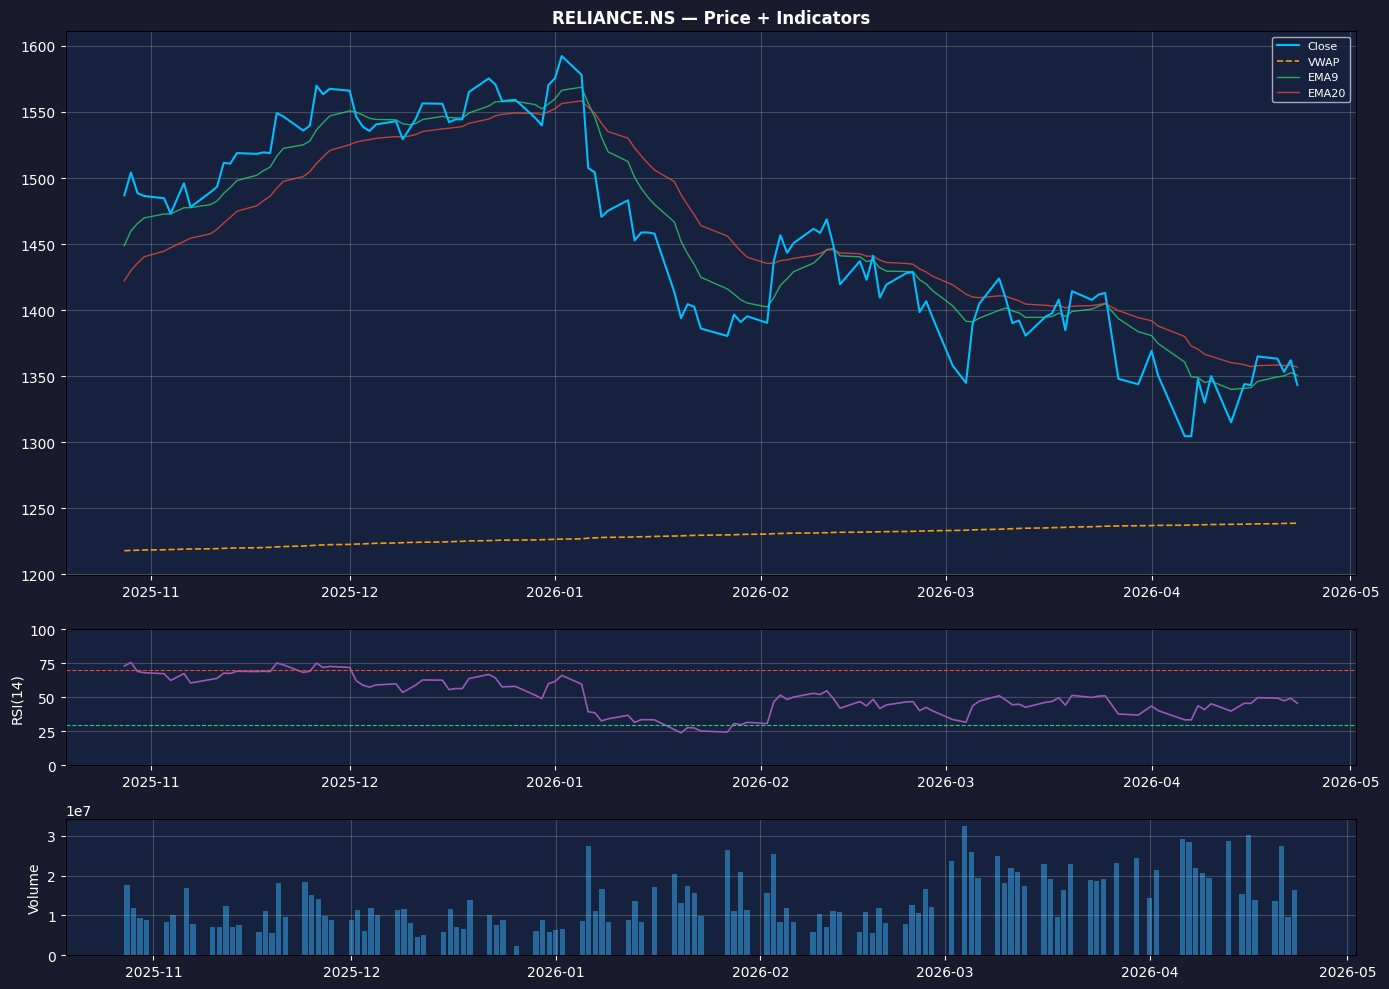

In [17]:
# STEP 5 — Visualise Price + Indicators
from evaluate import plot_price_with_indicators
PLOT_TIC = TICKERS[0]
plot_price_with_indicators(feat_df[feat_df.tic==PLOT_TIC].tail(120).copy(), PLOT_TIC, save_path=f"logs/indicators_{PLOT_TIC}.png")

In [18]:
# STEP 6 — Train Direction Models (all tickers)
import numpy as np, os, shutil
from models import build_model, load_model, DEVICE
from train import train_model, save_to_drive
from evaluate import plot_training_history
print(f"Device: {DEVICE}")
trained_models = {}
for TIC in TICKERS:
    print(f"
=== {TIC} ===")
    tic_df = feat_df[feat_df.tic==TIC].copy()
    if len(tic_df) < WINDOW+50: print(f"Skip {TIC}"); continue
    train_df, val_df, test_df = time_split(tic_df)
    scaler_path = f"models/scaler_{TIC}.pkl"
    X_train, X_val, X_test, scaler = fit_and_scale(train_df, val_df, test_df, FEATURE_COLS, method="standard", save_path=scaler_path)
    y_train = train_df.target_direction.values.astype("float32")
    y_val   = val_df.target_direction.values.astype("float32")
    y_test  = test_df.target_direction.values.astype("float32")
    X_tr_seq,y_tr_seq = make_sequences(X_train,y_train,window=WINDOW)
    X_vl_seq,y_vl_seq = make_sequences(X_val,  y_val,  window=WINDOW)
    X_te_seq,y_te_seq = make_sequences(X_test, y_test, window=WINDOW)
    mtype = "transformer" if USE_TRANSFORMER else "lstm_direction"
    model = build_model(mtype, input_size=len(FEATURE_COLS))
    local_ckpt = f"models/{mtype}_{TIC}.pt"
    drive_ckpt = f"{DRIVE_DIR}/models/{mtype}_{TIC}.pt"
    if os.path.exists(drive_ckpt): shutil.copy2(drive_ckpt,local_ckpt); model=load_model(model,local_ckpt); print("  Loaded from Drive.")
    history = train_model(model,X_tr_seq,y_tr_seq,X_vl_seq,y_vl_seq,task="classification",config=TRAIN_CONFIG,save_path=local_ckpt)
    try: save_to_drive(local_ckpt, DRIVE_DIR+"/models"); save_to_drive(scaler_path, DRIVE_DIR+"/models")
    except Exception as e: print(f"Drive save: {e}")
    trained_models[TIC] = {"model":model,"scaler":scaler,"X_test":X_te_seq,"y_test":y_te_seq,"test_df":test_df,"history":history}
    plot_training_history(history, save_path=f"logs/training_{TIC}.png")
print("All models trained!")

SyntaxError: unterminated f-string literal (detected at line 9) (1304035171.py, line 9)

In [ ]:
# STEP 7 — Evaluate on Test Set
from evaluate import predict_classification, eval_classification, plot_predicted_vs_actual, log_predictions
for TIC, bundle in trained_models.items():
    print(f"
--- {TIC} ---")
    probs = predict_classification(bundle["model"], bundle["X_test"])
    eval_classification(bundle["y_test"], probs)
    dates = bundle["test_df"]["date"].values[WINDOW:]
    log_predictions(dates, bundle["y_test"], probs, tic=TIC, label="direction")
    plot_predicted_vs_actual(dates, bundle["y_test"], probs, title=f"{TIC} — Prob vs Actual", save_path=f"logs/pred_vs_actual_{TIC}.png")

In [ ]:
# STEP 8 — Train High/Low Model
from sklearn.preprocessing import MinMaxScaler
hl_models = {}
for TIC in TICKERS:
    if TIC not in trained_models: continue
    print(f"
High/Low model: {TIC}")
    tic_df = feat_df[feat_df.tic==TIC].copy()
    train_df,val_df,test_df = time_split(tic_df)
    sc = trained_models[TIC]["scaler"]
    X_train,X_val,X_test = sc.transform(train_df[FEATURE_COLS].values), sc.transform(val_df[FEATURE_COLS].values), sc.transform(test_df[FEATURE_COLS].values)
    hl_sc = MinMaxScaler()
    y_tr_hl = hl_sc.fit_transform(train_df[["target_high","target_low"]].values)
    y_vl_hl = hl_sc.transform(val_df[["target_high","target_low"]].values)
    y_te_hl = hl_sc.transform(test_df[["target_high","target_low"]].values)
    X_tr_seq,y_tr_hl2 = make_sequences(X_train,y_tr_hl,window=WINDOW)
    X_vl_seq,y_vl_hl2 = make_sequences(X_val,y_vl_hl,window=WINDOW)
    X_te_seq,y_te_hl2 = make_sequences(X_test,y_te_hl,window=WINDOW)
    hl_model = build_model("high_low", input_size=len(FEATURE_COLS))
    hl_path = f"models/high_low_{TIC}.pt"
    train_model(hl_model,X_tr_seq,y_tr_hl2,X_vl_seq,y_vl_hl2,task="regression_hl",config={**TRAIN_CONFIG,"epochs":40},save_path=hl_path)
    try: save_to_drive(hl_path, DRIVE_DIR+"/models")
    except: pass
    hl_models[TIC] = {"model":hl_model,"scaler":hl_sc}
print("High/Low models done!")

In [ ]:
# STEP 9 — Signal Generation + Risk Management
from strategy import generate_signals, RISK_CONFIG
signal_dfs = {}
for TIC, bundle in trained_models.items():
    probs = predict_classification(bundle["model"], bundle["X_test"])
    test_aligned = bundle["test_df"].iloc[WINDOW:].copy().reset_index(drop=True)
    sig_df = generate_signals(test_aligned, probs, config={**RISK_CONFIG,"capital":CAPITAL})
    signal_dfs[TIC] = sig_df
    print(f"
{TIC} signals:")
    print(sig_df[["date","close","signal","prob_up","stop_loss","take_profit"]].tail(5))

In [ ]:
# STEP 10 — Backtesting
from backtest import run_backtest, walk_forward_backtest, plot_equity_curve
backtest_results = {}
for TIC, sig_df in signal_dfs.items():
    print(f"
Backtest: {TIC}")
    result = run_backtest(sig_df, capital=CAPITAL)
    backtest_results[TIC] = result
    plot_equity_curve(result, title=f"{TIC} Equity Curve", save_path=f"logs/equity_{TIC}.png")

In [ ]:
# STEP 11 — Summary + Save to Drive
import pandas as pd, shutil
rows = [{**r["metrics"], "ticker":t} for t,r in backtest_results.items()]
summary = pd.DataFrame(rows).set_index("ticker")
print("
📊 BACKTEST SUMMARY
", summary.to_string())
summary.to_csv(f"{DRIVE_DIR}/backtest_summary.csv")
try: shutil.copytree("logs", DRIVE_DIR+"/logs", dirs_exist_ok=True); print("Logs → Drive")
except Exception as e: print(e)

In [ ]:
# STEP 12 — Daily Continuous Learning Loop
# Run this cell EVERY DAY to update models with new market data
from continuous_learning import run_daily_loop
run_daily_loop(
    tickers=TICKERS,
    model_type="lstm_direction",
    retrain_on_last_n_days=90,
    drive_dir=DRIVE_DIR,
    use_intraday=USE_INTRADAY,
)